# CIFAR-10: Redes neuronales convolucionales

Este notebook estudia un problema de clasificación de imágenes sobre el conjunto de datos [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) utilizando modelos de aprendizaje profundo.

CIFAR-10 contiene 60.000 imágenes a color de 10 clases distintas, principalmente animales y vehículos. A diferencia de MNIST, las imágenes presentan mayor variabilidad visual: los objetos pueden aparecer en distintas posiciones, con diferentes poses, fondos y condiciones de imagen.

El objetivo del trabajo es comparar distintas arquitecturas de redes neuronales para clasificación de imágenes. Para ello, se parte de una red neuronal completamente conectada como modelo base y posteriormente se entrenan varias redes neuronales convolucionales, incluyendo modelos con regularización, batch normalization, dropout y aumento de datos.

El análisis incluye el entrenamiento de los modelos, la comparación de resultados, la evaluación sobre el conjunto de test y el estudio de la matriz de confusión final.


## Carga de los datos

In [1]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import pandas as pd
import keras.datasets.cifar10 as cifar10

from tensorflow import keras
from keras.utils import to_categorical

2025-06-01 22:13:59.990744: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-01 22:14:00.012810: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-01 22:14:00.108090: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-01 22:14:00.187584: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748808840.256190  133377 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748808840.27

In [2]:
# Primero, definimos los datos de entrenamiento, validación y prueba
(X, Y), (x_test, y_test) = cifar10.load_data()
(x_train, x_valid) = (X[:40000], X[40000:])
(y_train, y_valid) = (Y[:40000], Y[40000:])

In [3]:
# Normalizamos como de costumbre
x_train = x_train / 255.
x_valid = x_valid / 255.
x_test = x_test / 255.

In [ ]:
# Mapeo de etiquetas de clase de CIFAR-10
MAP_ELEMENTS = {
    0: 'avion', 1: 'coche', 2: 'ave',
    3: 'gato', 4: 'ciervo', 5: 'perro', 6: 'rana',
    7: 'caballo', 8: 'barco', 9: 'camion'
}

In [5]:
# Función auxiliar para convertir las etiquetas a codificación one-hot
def convert_to_one_hot(labels, num_classes):
    return np.squeeze(np.array([to_categorical(label, num_classes=num_classes) for label in labels]))

# Convertimos las etiquetas de entrenamiento, validación y prueba
num_classes = 10
y_train_one_hot = convert_to_one_hot(y_train, num_classes)
y_valid_one_hot = convert_to_one_hot(y_valid, num_classes)
y_test_one_hot = convert_to_one_hot(y_test, num_classes)

# Verificamos las conversiones
print(y_train_one_hot.shape)
print(y_valid_one_hot.shape)
print(y_test_one_hot.shape)

(40000, 10)
(10000, 10)
(10000, 10)


## Objetivo

El objetivo es entrenar y comparar distintas arquitecturas de redes neuronales para clasificación de imágenes sobre CIFAR-10.

Para ello, se evalúa una red completamente conectada como modelo base y posteriormente se entrenan varias redes neuronales convolucionales. El análisis compara el comportamiento durante el entrenamiento, el rendimiento en validación y la precisión final sobre el conjunto de test.


In [6]:
from keras.models import Sequential
from keras.layers import Flatten, Dense, Dropout
from keras.optimizers import Adam
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

Número total de clases: 10
Clases: ['avion', 'coche', 'ave', 'gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camion']


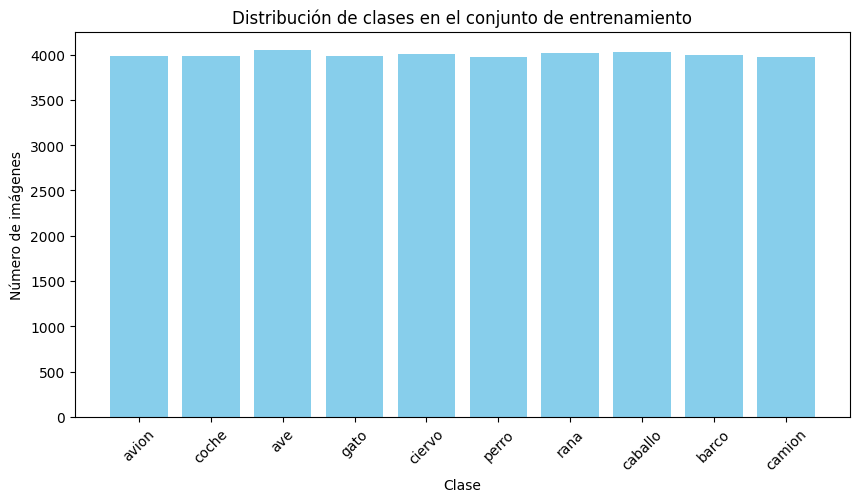

/tmp/ipykernel_133377/2287403762.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax.set_title(MAP_ELEMENTS[int(y_train[i])])


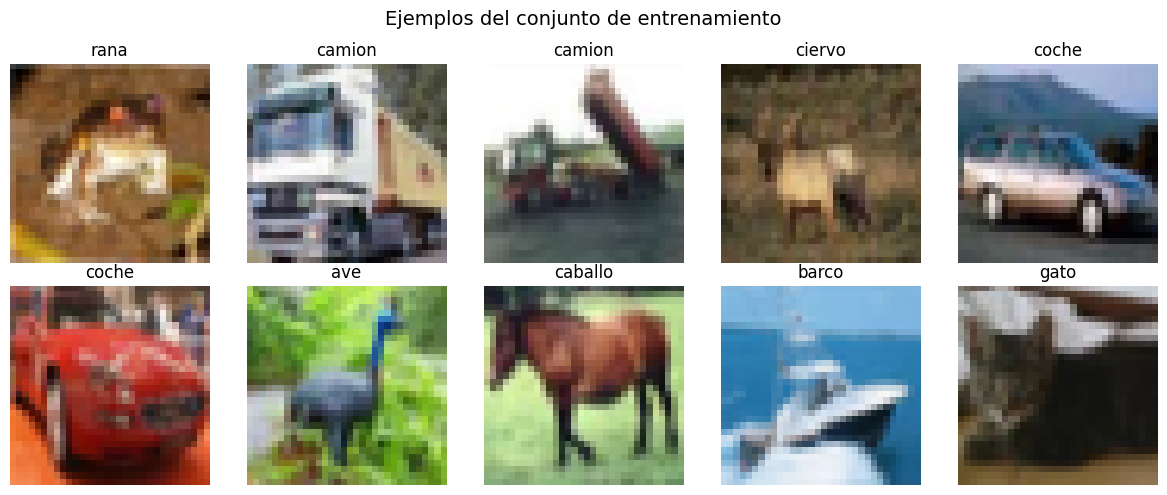

In [7]:
#Análisis de datos
# Clases presentes en CIFAR-10
import numpy as np
import matplotlib.pyplot as plt

classes = list(MAP_ELEMENTS.values())

print("Número total de clases:", len(classes))
print("Clases:", classes)

# Ver distribución de clases en entrenamiento
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10,5))
plt.bar([MAP_ELEMENTS[int(u)] for u in unique], counts, color="skyblue")
plt.xticks(rotation=45)
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Número de imágenes")
plt.show()

# Ver algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(x_train[i])
    ax.set_title(MAP_ELEMENTS[int(y_train[i])])
    ax.axis('off')
plt.suptitle("Ejemplos del conjunto de entrenamiento", fontsize=14)
plt.tight_layout()
plt.show()

### Análisis del dataset CIFAR-10

- El dataset CIFAR-10 contiene 60.000 imágenes a color (32x32 píxeles), distribuidas en 10 clases equilibradas (6.000 imágenes por clase).
- A diferencia de MNIST, que tiene imágenes en escala de grises y centradas, CIFAR-10 incluye objetos con fondo, diferentes orientaciones y ruido visual, lo que lo convierte en un conjunto más complejo y más realista.
- Las clases están balanceadas, lo que permite usar métricas como accuracy sin riesgo de sesgo por clase dominante.
- Las imágenes son pequeñas, lo cual limita el detalle visual que puede extraerse, lo que hace más importante la calidad de las arquitecturas y la regularización.

Comenzamos con una red completamente conectada como línea base. Aunque este tipo de arquitectura no está diseñada específicamente para trabajar con imágenes, permite comparar su rendimiento con el de las redes convolucionales y valorar la mejora aportada por una arquitectura especializada.

In [8]:
# Modelo Fully connected

# Definimos el modelo fully connected
fc_model = Sequential([
    Flatten(input_shape=(32, 32, 3)),  # Aplana la imagen
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 clases
])

# Compilamos el modelo
fc_model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Mostramos resumen del modelo
fc_model.summary()


/home/carlos/miniconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1748808846.108297  133377 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1748808846.110760  133377 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
fc_history = fc_model.fit(
    x_train, y_train_one_hot,
    epochs=20,
    batch_size=128,
    validation_data=(x_valid, y_valid_one_hot)
)

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.2017 - loss: 2.2067 - val_accuracy: 0.3139 - val_loss: 1.9143
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.2913 - loss: 1.9292 - val_accuracy: 0.3518 - val_loss: 1.8326
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3192 - loss: 1.8676 - val_accuracy: 0.3650 - val_loss: 1.7833
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3258 - loss: 1.8384 - val_accuracy: 0.3755 - val_loss: 1.7688
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3414 - loss: 1.8082 - val_accuracy: 0.3921 - val_loss: 1.7385
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3456 - loss: 1.7935 - val_accuracy: 0.3908 - val_loss: 1.7291
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3545 - loss: 1.7752 - val_accuracy: 0.3880 - val_loss: 1.7428
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.3612 - loss: 1.7611 - val_accu

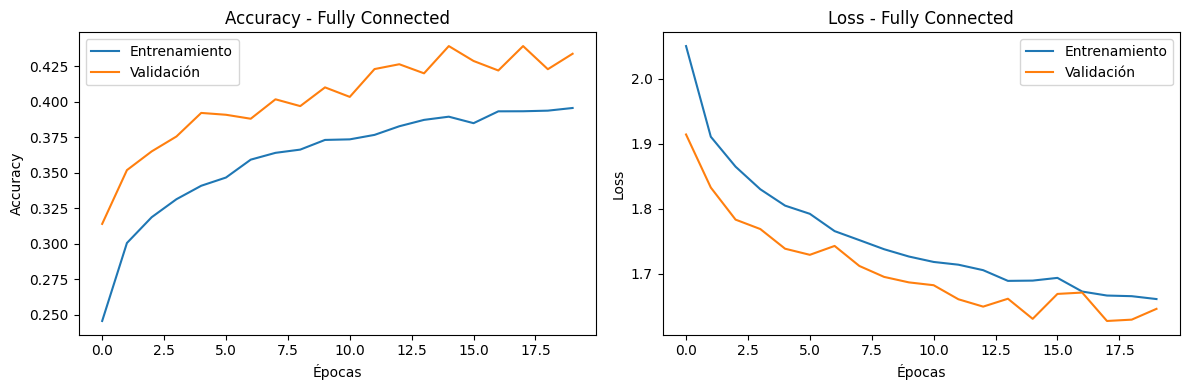

In [10]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    plt.figure(figsize=(12,4))
    
    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Entrenamiento')
    plt.plot(history.history['val_accuracy'], label='Validación')
    plt.title(f'Accuracy - {title}')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Entrenamiento')
    plt.plot(history.history['val_loss'], label='Validación')
    plt.title(f'Loss - {title}')
    plt.xlabel('Épocas')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(fc_history, "Fully Connected")

In [11]:
test_loss, test_acc = fc_model.evaluate(x_test, y_test_one_hot)
print(f"Accuracy en test (modelo Fully Connected): {test_acc:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4313 - loss: 1.6293
Accuracy en test (modelo Fully Connected): 43.39%


La red completamente conectada obtiene un rendimiento limitado en CIFAR-10, algo esperable porque este tipo de arquitectura no aprovecha explícitamente la estructura espacial de las imágenes.

A continuación se entrenan y comparan varias arquitecturas convolucionales:

* Una CNN básica.
* Una CNN más profunda con regularización adicional.
* Una CNN básica con aumento de datos.
* Una CNN avanzada con aumento de datos.

In [12]:
# CNN Clásica
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

cnn_model.summary()


/home/carlos/miniconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
cnn_history = cnn_model.fit(
    x_train, y_train_one_hot,
    epochs=20,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot)
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.3378 - loss: 1.9165 - val_accuracy: 0.4727 - val_loss: 1.4677
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - accuracy: 0.5113 - loss: 1.3606 - val_accuracy: 0.5629 - val_loss: 1.3166
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.5950 - loss: 1.1452 - val_accuracy: 0.6269 - val_loss: 1.0908
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6496 - loss: 0.9950 - val_accuracy: 0.6856 - val_loss: 0.9125
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.6917 - loss: 0.8899 - val_accuracy: 0.7074 - val_loss: 0.8869
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.7138 - loss: 0.8123 - val_accuracy: 0.6866 - val_loss: 0.9199
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.7405 - loss: 0.7448 - val_accuracy: 0.7134 - val_loss: 0.8454
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.7644 - loss: 0.6755 - 

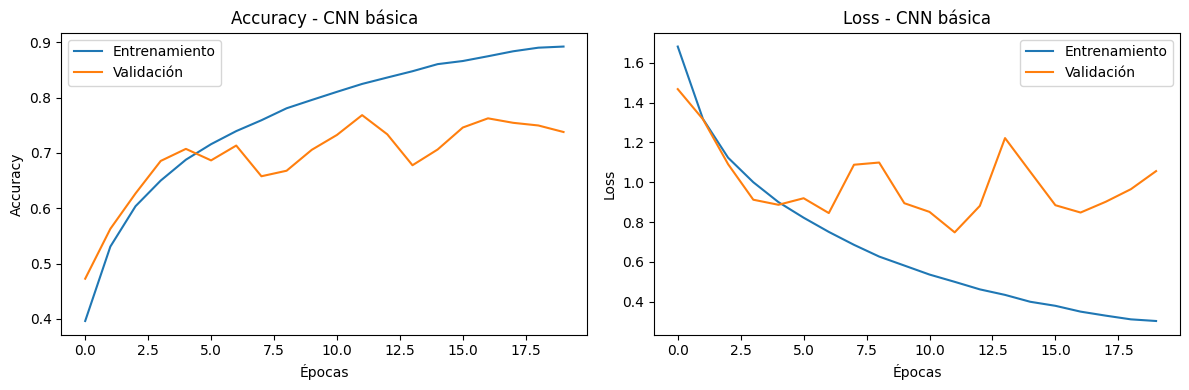

In [14]:
plot_history(cnn_history, "CNN básica")

In [15]:
test_loss, test_acc = cnn_model.evaluate(x_test, y_test_one_hot)
print(f"Accuracy en test (CNN básica): {test_acc:.2%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7318 - loss: 1.0554
Accuracy en test (CNN básica): 73.04%


Vemos que mejora significativamente los resultados con respecto a las Fully Connected. 
Esto ya podría ser un modelo a utilizar para clasificar estas imágenes, aunque no tenemos rendimientos maníficos. 
Vamos a ver si aplicando alguna los otros cambios mejoramos alguno de los modelos. 

In [16]:
# Evaluación modelo Fully Connected
fc_train_acc = fc_history.history['accuracy'][-1]
fc_val_acc = fc_history.history['val_accuracy'][-1]
fc_test_loss, fc_test_acc = fc_model.evaluate(x_test, y_test_one_hot)

# Evaluación modelo CNN
cnn_train_acc = cnn_history.history['accuracy'][-1]
cnn_val_acc = cnn_history.history['val_accuracy'][-1]
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test, y_test_one_hot)

# Mostrar tabla
import pandas as pd
pd.DataFrame({
    "Modelo": ["Fully Connected", "CNN Básica"],
    "Accuracy Train": [fc_train_acc, cnn_train_acc],
    "Accuracy Validación": [fc_val_acc, cnn_val_acc],
    "Accuracy Test": [fc_test_acc, cnn_test_acc]
})

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4313 - loss: 1.6293
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7318 - loss: 1.0554


,Modelo,Accuracy Train,Accuracy Validación,Accuracy Test
0,Fully Connected,0.395575,0.4338,0.4339
1,CNN Básica,0.892350,0.7379,0.7304


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


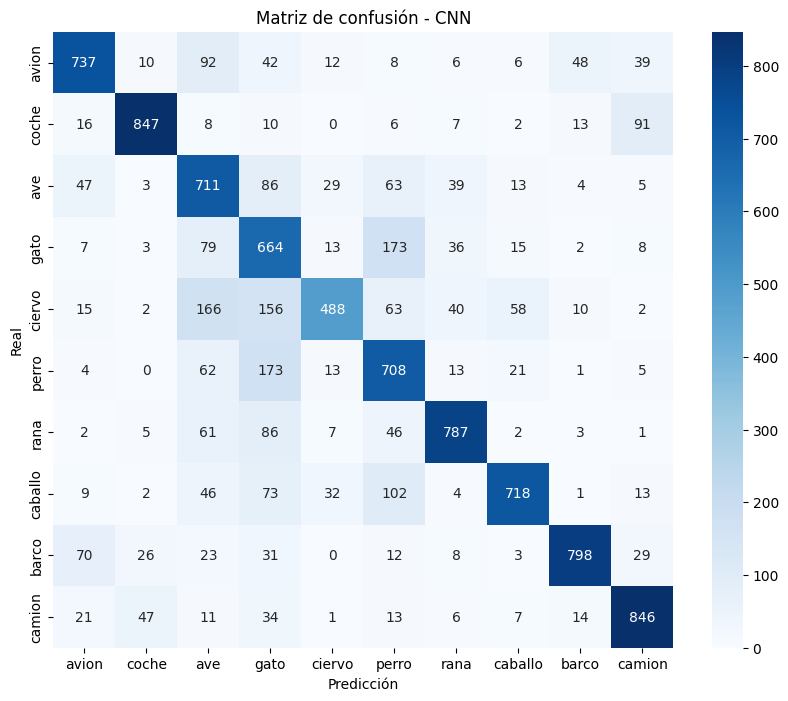

In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predicciones
y_pred_probs = cnn_model.predict(x_test)
y_pred_labels = y_pred_probs.argmax(axis=1)

# TRUE labels — usa esta línea si y_test tiene shape (10000, 1)
y_true_labels = y_test.flatten()

# Matriz de confusión
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)

# Visualización
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(MAP_ELEMENTS.values()),
            yticklabels=list(MAP_ELEMENTS.values()))
plt.title("Matriz de confusión - CNN")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

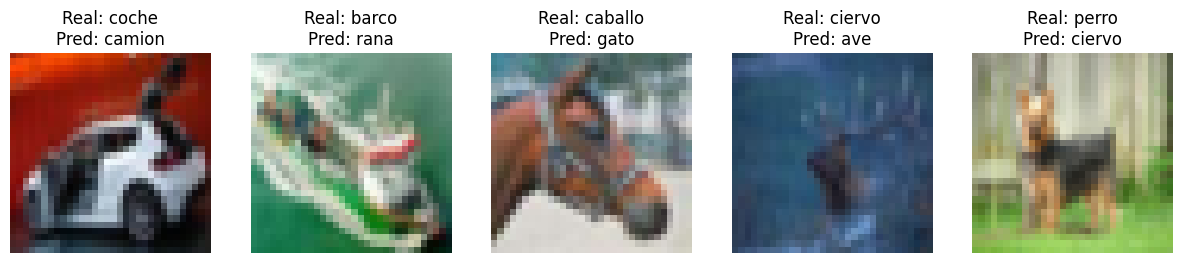

In [18]:
import numpy as np

# Índices donde falla
errores = np.where(y_pred_labels != y_true_labels)[0]

# Visualizar los 5 primeros errores
plt.figure(figsize=(15, 5))
for i, idx in enumerate(errores[:5]):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx])
    true_label = MAP_ELEMENTS[y_true_labels[idx]]
    pred_label = MAP_ELEMENTS[y_pred_labels[idx]]
    plt.title(f"Real: {true_label}\nPred: {pred_label}")
    plt.axis("off")

In [19]:
# Vamos ahora a usar una CNN avanzada, a ver que resultados obtenemos y posteriormente aplicaremos técnicas de data augmentation.
# Después de eso volveremos a comparar todas y analizaremos los resultados.
cnn_advanced = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.4),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_advanced.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
cnn_advanced.summary()

/home/carlos/miniconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 56ms/step - accuracy: 0.2699 - loss: 2.2341 - val_accuracy: 0.4345 - val_loss: 1.8401
Epoch 2/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.4553 - loss: 1.4956 - val_accuracy: 0.5614 - val_loss: 1.2578
Epoch 3/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.5412 - loss: 1.2862 - val_accuracy: 0.5984 - val_loss: 1.2195
Epoch 4/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.6005 - loss: 1.1293 - val_accuracy: 0.6806 - val_loss: 0.9207
Epoch 5/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 51ms/step - accuracy: 0.6395 - loss: 1.0301 - val_accuracy: 0.6766 - val_loss: 0.9442
Epoch 6/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.6684 - loss: 0.9599 - val_accuracy: 0.7055 - val_loss: 0.8377
Epoch 7/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.6863 - loss: 0.9029 - val_accuracy: 0.7317 - val_loss: 0.8025
Epoch 8/25
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 57ms/step - accuracy: 0.7048 - loss: 0.8604 - 

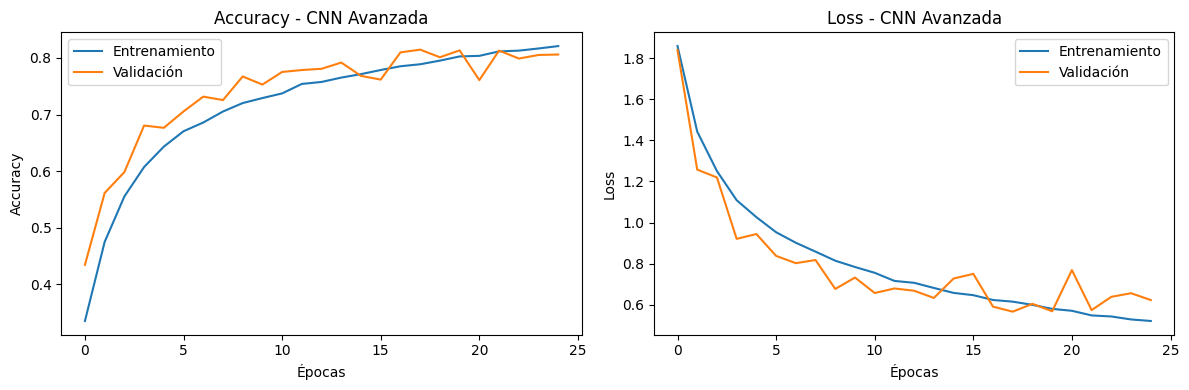

In [20]:
cnn_adv_history = cnn_advanced.fit(
    x_train, y_train_one_hot,
    epochs=25,
    batch_size=64,
    validation_data=(x_valid, y_valid_one_hot)
)

plot_history(cnn_adv_history, "CNN Avanzada")

Epoch 1/30


/home/carlos/miniconda3/envs/py312/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 32ms/step - accuracy: 0.3276 - loss: 1.9419 - val_accuracy: 0.5105 - val_loss: 1.3458
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.4891 - loss: 1.4363 - val_accuracy: 0.6124 - val_loss: 1.0863
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.5465 - loss: 1.2834 - val_accuracy: 0.5921 - val_loss: 1.1732
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.5852 - loss: 1.1752 - val_accuracy: 0.6334 - val_loss: 1.0339
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 22s 36ms/step - accuracy: 0.6214 - loss: 1.0865 - val_accuracy: 0.4875 - val_loss: 1.7067
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.6422 - loss: 1.0281 - val_accuracy: 0.6962 - val_loss: 0.8480
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 36ms/step - accuracy: 0.6614 - loss: 0.9811 - val_accuracy: 0.7214 - val_loss: 0.8043
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.6749 - loss: 0.9386 - val_accurac

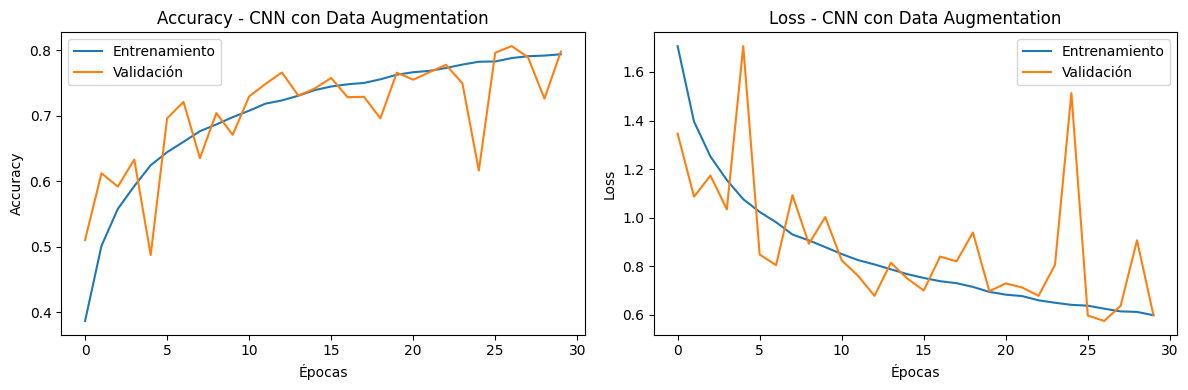

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

cnn_aug = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamiento con imágenes aumentadas
cnn_aug_history = cnn_aug.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=64),
    epochs=30,
    validation_data=(x_valid, y_valid_one_hot)
)

plot_history(cnn_aug_history, "CNN con Data Augmentation")

In [22]:
cnn_adv_aug = keras.models.clone_model(cnn_advanced)
cnn_adv_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_adv_aug_history = cnn_adv_aug.fit(
    datagen.flow(x_train, y_train_one_hot, batch_size=64),
    epochs=30,
    validation_data=(x_valid, y_valid_one_hot)
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 51ms/step - accuracy: 0.2245 - loss: 2.3185 - val_accuracy: 0.3179 - val_loss: 2.3753
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.3862 - loss: 1.6541 - val_accuracy: 0.3469 - val_loss: 2.4795
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.4586 - loss: 1.4805 - val_accuracy: 0.4852 - val_loss: 1.6240
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.5199 - loss: 1.3417 - val_accuracy: 0.5237 - val_loss: 1.4337
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 54ms/step - accuracy: 0.5550 - loss: 1.2446 - val_accuracy: 0.2609 - val_loss: 3.2440
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.5898 - loss: 1.1674 - val_accuracy: 0.5877 - val_loss: 1.2779
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6166 - loss: 1.0898 - val_accuracy: 0.6721 - val_loss: 0.9677
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.6331 - loss: 1.0471 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7854 - loss: 0.6533
Accuracy en test (CNN Avanzada + Augmentation): 78.82%


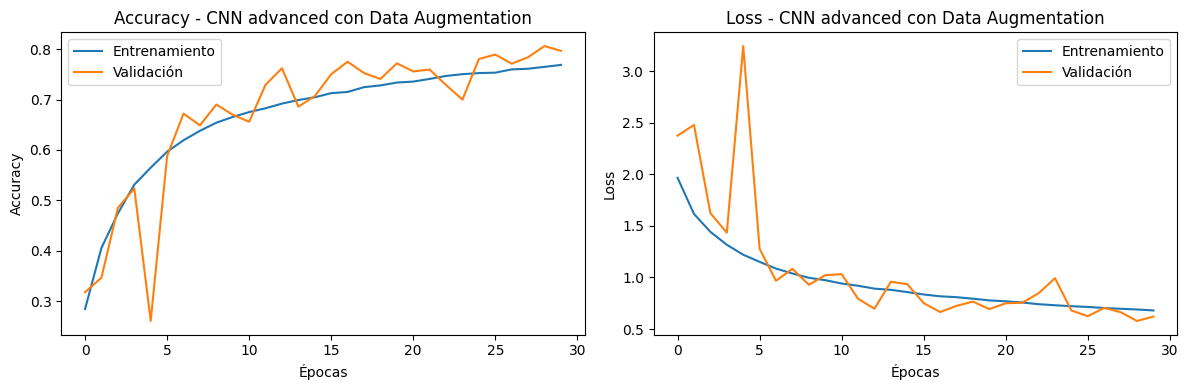

In [23]:
cnn_adv_aug_test_loss, cnn_adv_aug_test_acc = cnn_adv_aug.evaluate(x_test, y_test_one_hot)
print(f"Accuracy en test (CNN Avanzada + Augmentation): {cnn_adv_aug_test_acc:.2%}")

plot_history(cnn_adv_aug_history, "CNN advanced con Data Augmentation")

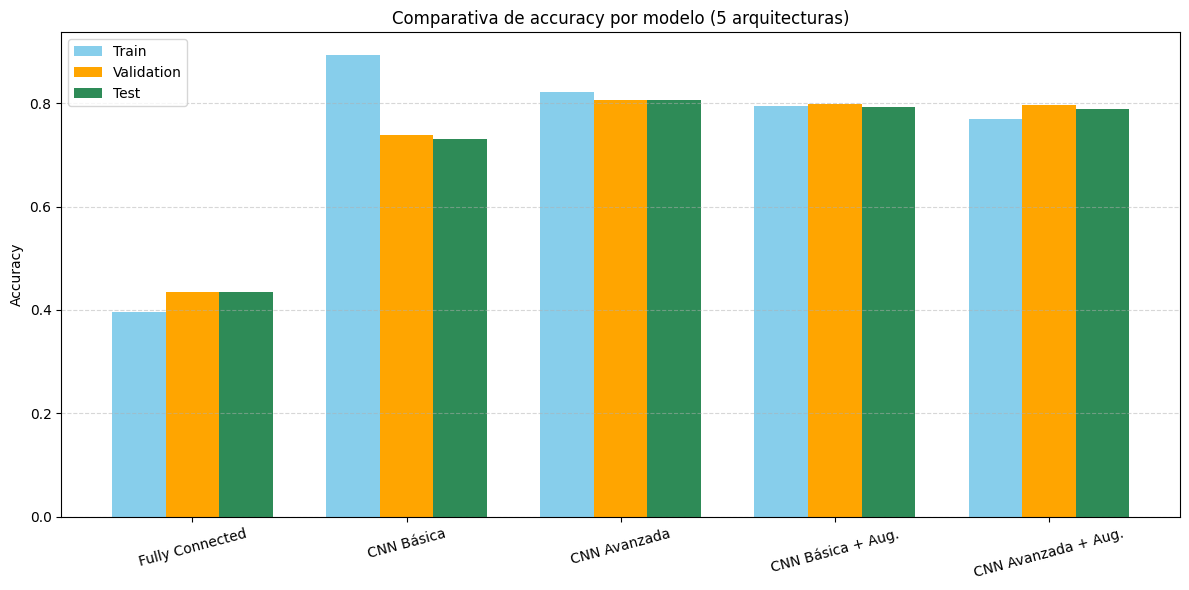

In [24]:
# Evalúa todos los modelos con los valores reales de tus history
fc_train_acc = fc_history.history['accuracy'][-1]
fc_val_acc = fc_history.history['val_accuracy'][-1]
fc_test_acc = fc_model.evaluate(x_test, y_test_one_hot, verbose=0)[1]

cnn_train_acc = cnn_history.history['accuracy'][-1]
cnn_val_acc = cnn_history.history['val_accuracy'][-1]
cnn_test_acc = cnn_model.evaluate(x_test, y_test_one_hot, verbose=0)[1]

cnn_adv_train_acc = cnn_adv_history.history['accuracy'][-1]
cnn_adv_val_acc = cnn_adv_history.history['val_accuracy'][-1]
cnn_adv_test_acc = cnn_advanced.evaluate(x_test, y_test_one_hot, verbose=0)[1]

cnn_aug_train_acc = cnn_aug_history.history['accuracy'][-1]
cnn_aug_val_acc = cnn_aug_history.history['val_accuracy'][-1]
cnn_aug_test_acc = cnn_aug.evaluate(x_test, y_test_one_hot, verbose=0)[1]

cnn_adv_aug_train_acc = cnn_adv_aug_history.history['accuracy'][-1]
cnn_adv_aug_val_acc = cnn_adv_aug_history.history['val_accuracy'][-1]
cnn_adv_aug_test_acc = cnn_adv_aug.evaluate(x_test, y_test_one_hot, verbose=0)[1]

# DataFrame
results_df = pd.DataFrame({
    "Modelo": [
        "Fully Connected",
        "CNN Básica",
        "CNN Avanzada",
        "CNN Básica + Aug.",
        "CNN Avanzada + Aug."
    ],
    "Train Accuracy": [fc_train_acc, cnn_train_acc, cnn_adv_train_acc, cnn_aug_train_acc, cnn_adv_aug_train_acc],
    "Val Accuracy":   [fc_val_acc, cnn_val_acc, cnn_adv_val_acc, cnn_aug_val_acc, cnn_adv_aug_val_acc],
    "Test Accuracy":  [fc_test_acc, cnn_test_acc, cnn_adv_test_acc, cnn_aug_test_acc, cnn_adv_aug_test_acc]
})

# Gráfico de barras
x = range(len(results_df))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar([p - width for p in x], results_df["Train Accuracy"], width=width, label='Train', color='skyblue')
plt.bar(x, results_df["Val Accuracy"], width=width, label='Validation', color='orange')
plt.bar([p + width for p in x], results_df["Test Accuracy"], width=width, label='Test', color='seagreen')

plt.xticks(ticks=x, labels=results_df["Modelo"], rotation=15)
plt.ylabel("Accuracy")
plt.title("Comparativa de accuracy por modelo (5 arquitecturas)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

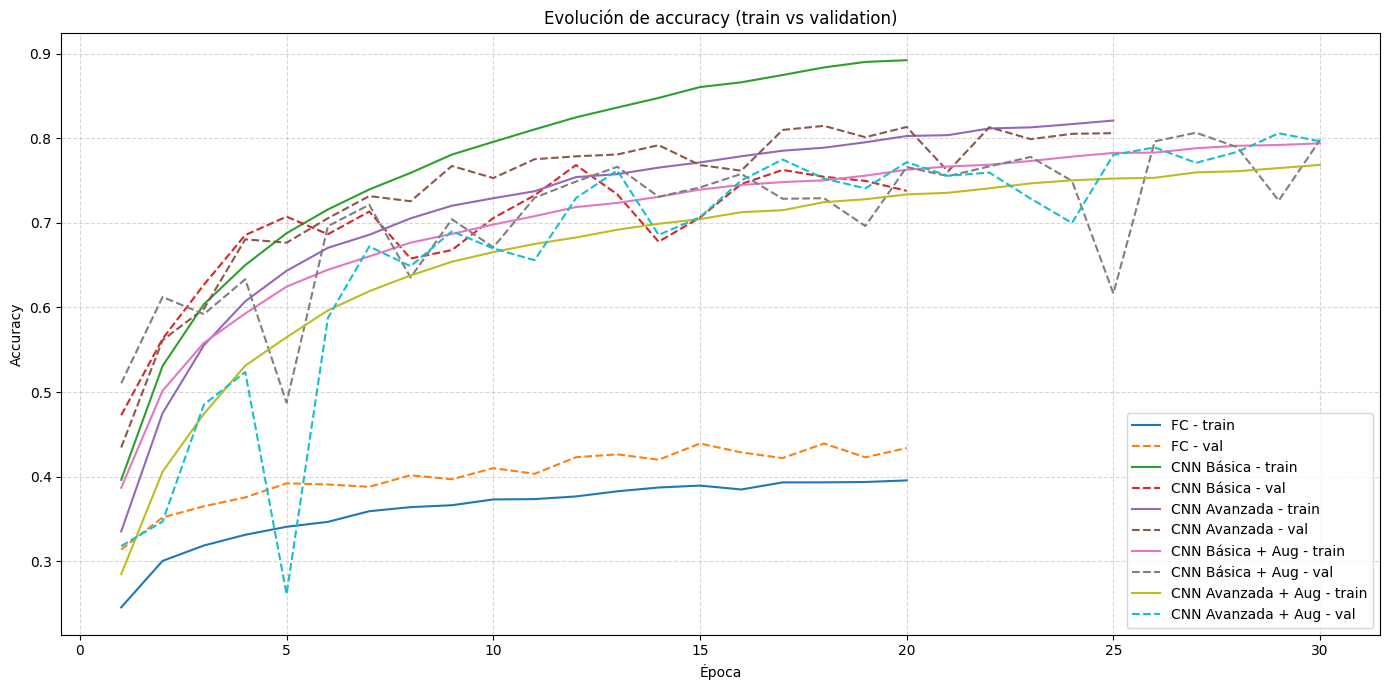

In [25]:
plt.figure(figsize=(14, 7))

# Fully Connected
plt.plot(range(1, len(fc_history.history['accuracy']) + 1),
         fc_history.history['accuracy'], label="FC - train", linestyle='-')
plt.plot(range(1, len(fc_history.history['val_accuracy']) + 1),
         fc_history.history['val_accuracy'], label="FC - val", linestyle='--')

# CNN Básica
plt.plot(range(1, len(cnn_history.history['accuracy']) + 1),
         cnn_history.history['accuracy'], label="CNN Básica - train", linestyle='-')
plt.plot(range(1, len(cnn_history.history['val_accuracy']) + 1),
         cnn_history.history['val_accuracy'], label="CNN Básica - val", linestyle='--')

# CNN Avanzada
plt.plot(range(1, len(cnn_adv_history.history['accuracy']) + 1),
         cnn_adv_history.history['accuracy'], label="CNN Avanzada - train", linestyle='-')
plt.plot(range(1, len(cnn_adv_history.history['val_accuracy']) + 1),
         cnn_adv_history.history['val_accuracy'], label="CNN Avanzada - val", linestyle='--')

# CNN Básica + Aug
plt.plot(range(1, len(cnn_aug_history.history['accuracy']) + 1),
         cnn_aug_history.history['accuracy'], label="CNN Básica + Aug - train", linestyle='-')
plt.plot(range(1, len(cnn_aug_history.history['val_accuracy']) + 1),
         cnn_aug_history.history['val_accuracy'], label="CNN Básica + Aug - val", linestyle='--')

# CNN Avanzada + Aug
plt.plot(range(1, len(cnn_adv_aug_history.history['accuracy']) + 1),
         cnn_adv_aug_history.history['accuracy'], label="CNN Avanzada + Aug - train", linestyle='-')
plt.plot(range(1, len(cnn_adv_aug_history.history['val_accuracy']) + 1),
         cnn_adv_aug_history.history['val_accuracy'], label="CNN Avanzada + Aug - val", linestyle='--')

# Personalización del gráfico
plt.title("Evolución de accuracy (train vs validation)")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



El gráfico conjunto de accuracy (entrenamiento vs. validación) revela que el modelo CNN Avanzado sin augmentación logra el mejor equilibrio entre capacidad de aprendizaje y generalización. Las curvas de entrenamiento y validación son cercanas y estables, lo que indica un entrenamiento robusto. Por el contrario, los modelos con data augmentation, si bien muestran estabilidad, no logran superar la arquitectura avanzada entrenada sin ruido sintético. Esto sugiere que, en este caso, el modelo ya generalizaba suficientemente bien con los datos originales. Si vemos que mejora utilizar una CNN avanzada respecto a una simple (no mucho pero sí suficientemente mejor, de cara a la validación)

## Conclusiones finales

En este proyecto se han entrenado y evaluado cinco arquitecturas distintas sobre el conjunto de imágenes CIFAR-10, con el objetivo de maximizar la accuracy de clasificación utilizando redes neuronales convolucionales.

### Comparativa de modelos

- **Fully Connected**: sirvió como modelo de referencia base. Su bajo rendimiento confirma que las redes densas no son adecuadas para imágenes, al no capturar estructura espacial.
- **CNN Básica**: introdujo convoluciones y pooling, mejorando sensiblemente la performance. No obstante, su arquitectura poco profunda y sin normalización la hizo susceptible a un leve sobreajuste.
- **CNN Avanzada**: incrementó la profundidad, incorporó `BatchNormalization` y `Dropout`, mostrando un excelente balance entre entrenamiento y validación. Fue el modelo más eficaz sin necesidad de augmentación.
- **CNN con Data Augmentation**: al aplicarse a la CNN básica, redujo el sobreajuste y estabilizó la curva de validación, aunque sin superar al modelo avanzado.
- **CNN Avanzada + Augmentation**: no logró mejorar los resultados respecto al modelo avanzado sin augmentación, probablemente debido a un exceso de regularización y la necesidad de más épocas.

### Análisis visual y métricas

- Las clases más difíciles de predecir fueron aquellas visualmente similares: gato/perro, ciervo/caballo.
- El análisis de errores mostró que los fallos ocurren en imágenes con objetos poco contrastados, parcialmente visibles o en posiciones poco comunes.
- Las curvas de entrenamiento y validación reflejan la capacidad de generalización de cada modelo, especialmente la arquitectura avanzada.

### Conclusión general

El mejor modelo fue la **CNN Avanzada sin data augmentation**, por su rendimiento alto, estable y generalizable. Esta práctica confirma que en visión por computador no basta con añadir capas: el diseño cuidadoso de la arquitectura y el control del overfitting son fundamentales para un buen desempeño.